Mortgage Approvals Prediction Model
Objective

The objective of this notebook is to predict Mortgage Approvals using UK macroeconomic and retail banking variables. Feature engineering and normalization are performed before model training, and four regression models are compared: Linear Regression, Random Forest and  XGBoost.

**Import Libraries**

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

**Load the Dataset**

In [17]:
df = pd.read_csv("FINAL_DS.csv")

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date").reset_index(drop=True)

df.head()

,Date,Year,Month,Bank_Rate,CPI,Unemployment_Rate,House_Price_Index,GDP_Growth,Current_Accounts,Savings_Accounts,Mortgage_Approvals,Consumer_Credit,Credit_Card_Lending
0,2008-01-01,2008,January,5.50,2.2,5.2,65.6,0.4,33417,224159,71326,101598,54232
1,2008-02-01,2008,February,5.25,2.5,5.2,65.0,0.4,31492,226772,71064,102081,54375
2,2008-03-01,2008,March,5.25,2.5,5.3,64.5,0.4,32823,227769,60454,101945,54471
3,2008-04-01,2008,April,5.00,3.0,5.2,64.7,-0.5,31895,233766,57134,101756,54404
4,2008-05-01,2008,May,5.00,3.3,5.4,65.1,-0.5,32210,237820,40546,101556,55211


**Feature Engineering**


In [18]:
# Create lag features for Mortgage Approvals
df["Mortgage_Lag1"] = df["Mortgage_Approvals"].shift(1)



**Feature Selection**

In [19]:
features = [
    "Bank_Rate",
    "CPI",
    "GDP_Growth",
    "Unemployment_Rate",
    "Mortgage_Lag1"
]

# Create modelling dataframe and remove rows with missing lag values
df_model = df[features + ["Mortgage_Approvals"]].dropna().reset_index(drop=True)

X = df_model[features]
y = df_model["Mortgage_Approvals"]

print(X.shape, y.shape)

(215, 5) (215,)


**Correlation Analysis**

In [20]:
# Correlation matrix
corr_matrix = df_model[features + ["Mortgage_Approvals"]].corr()

# Display correlation with the target variable
mortgage_corr = corr_matrix["Mortgage_Approvals"].sort_values(ascending=False)

mortgage_corr

Mortgage_Approvals    1.000000
Mortgage_Lag1         0.915999
GDP_Growth            0.499815
Bank_Rate            -0.250156
CPI                  -0.333890
Unemployment_Rate    -0.365782
Name: Mortgage_Approvals, dtype: float64

**Multicollinearity Analysis (VIF)**

In [21]:
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data = vif_data.sort_values(by="VIF", ascending=False)

vif_data

,Feature,VIF
4,Mortgage_Lag1,7.100100
3,Unemployment_Rate,6.852058
1,CPI,2.930805
0,Bank_Rate,1.936399
2,GDP_Growth,1.068041


**Chronological train/test split**

In [22]:
split = int(len(df_model) * 0.8)

train = df_model.iloc[:split]
test = df_model.iloc[split:]

X_train = train[features]
X_test = test[features]

y_train = train["Mortgage_Approvals"]
y_test = test["Mortgage_Approvals"]

print(X_train.shape, X_test.shape)

(172, 5) (43, 5)


**Standardize the features**

In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape, X_test_scaled.shape)

(172, 5) (43, 5)


**Linear Regression Model**

In [24]:
# Train the Linear Regression model
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_lr = lr_model.predict(X_test_scaled)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


**Linear Regression Evaluation**

In [25]:
lr_r2 = r2_score(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression Results")
print("R² Score :", round(lr_r2, 4))
print("MAE      :", round(lr_mae, 2))
print("RMSE     :", round(lr_rmse, 2))

Linear Regression Results
R² Score : 0.4257
MAE      : 5535.46
RMSE     : 6268.42


**Linear Regression Coefficients**

In [26]:
# Linear Regression Coefficients

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr_model.coef_
})

coef_df = coef_df.sort_values(by="Coefficient", ascending=False)

coef_df

,Feature,Coefficient
4,Mortgage_Lag1,10299.443378
2,GDP_Growth,3293.948838
1,CPI,-974.066528
3,Unemployment_Rate,-1386.884353
0,Bank_Rate,-1569.743112


**Ordinary Least Squares (OLS) Regression**

In [27]:
import statsmodels.api as sm

# Add intercept term
X_train_sm = sm.add_constant(X_train_scaled)

# Fit OLS model
ols_model = sm.OLS(y_train, X_train_sm).fit()

# Display statistical summary
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:     Mortgage_Approvals   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.893
Method:                 Least Squares   F-statistic:                     286.9
Date:                Wed, 19 Aug 2026   Prob (F-statistic):           1.01e-79
Time:                        01:45:49   Log-Likelihood:                -1693.4
No. Observations:                 172   AIC:                             3399.
Df Residuals:                     166   BIC:                             3418.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.062e+04    354.492    171.000      0.0

**Actual vs Predicted Mortgage Approvals**

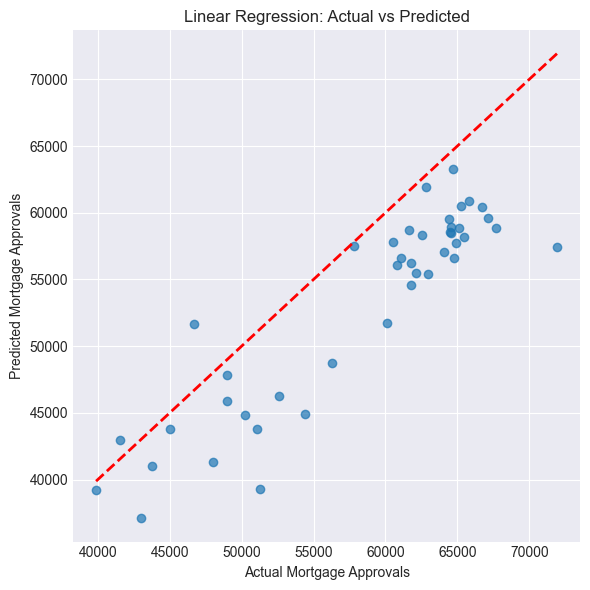

In [28]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_lr, alpha=0.7)

# 45-degree reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)

plt.xlabel("Actual Mortgage Approvals")
plt.ylabel("Predicted Mortgage Approvals")
plt.title("Linear Regression: Actual vs Predicted")
plt.tight_layout()
plt.show()

**Residual Analysis**

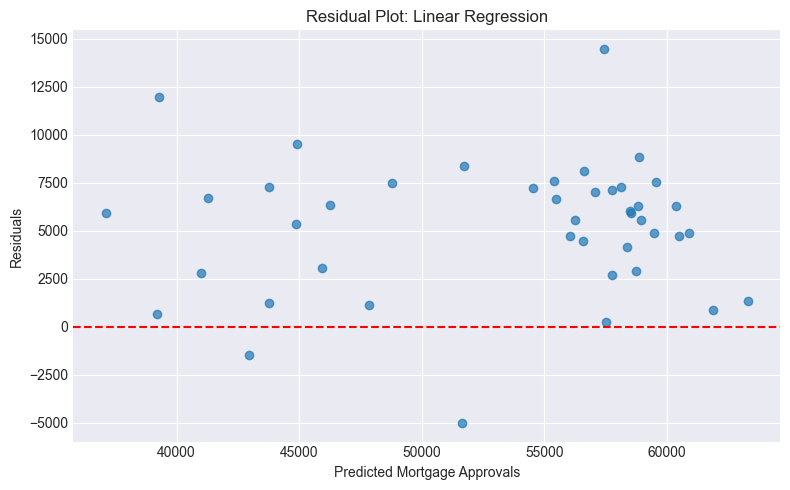

In [29]:
# Calculate residuals
residuals = y_test - y_pred_lr

plt.figure(figsize=(8,5))

plt.scatter(y_pred_lr, residuals, alpha=0.7)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Mortgage Approvals")
plt.ylabel("Residuals")
plt.title("Residual Plot: Linear Regression")
plt.tight_layout()
plt.show()

**Random Forest Regression**

In [30]:
from sklearn.ensemble import RandomForestRegressor

# Train the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Generate predictions
y_pred_rf = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


**Random Forest Feature Importance**

In [31]:
# Random Forest Feature Importance

rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(by="Importance", ascending=False)

rf_importance

,Feature,Importance
4,Mortgage_Lag1,0.830604
2,GDP_Growth,0.089242
3,Unemployment_Rate,0.058109
1,CPI,0.012594
0,Bank_Rate,0.009451


**Random Forest Evaluation**

In [32]:
rf_r2 = r2_score(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest Results")
print("R² Score :", round(rf_r2, 4))
print("MAE      :", round(rf_mae, 2))
print("RMSE     :", round(rf_rmse, 2))

Random Forest Results
R² Score : 0.6893
MAE      : 3367.13
RMSE     : 4610.73


**Actual vs Predicted Mortgage Approvals**

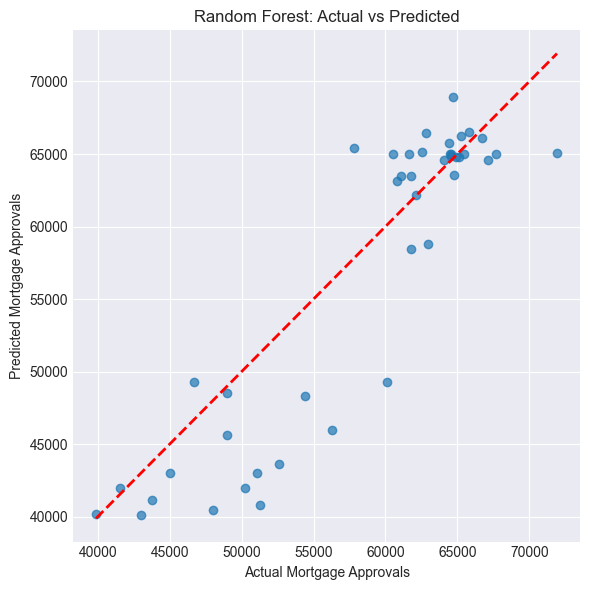

In [33]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_rf, alpha=0.7)

# 45-degree reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)

plt.xlabel("Actual Mortgage Approvals")
plt.ylabel("Predicted Mortgage Approvals")
plt.title("Random Forest: Actual vs Predicted")
plt.tight_layout()
plt.show()

**Residual Analysis**

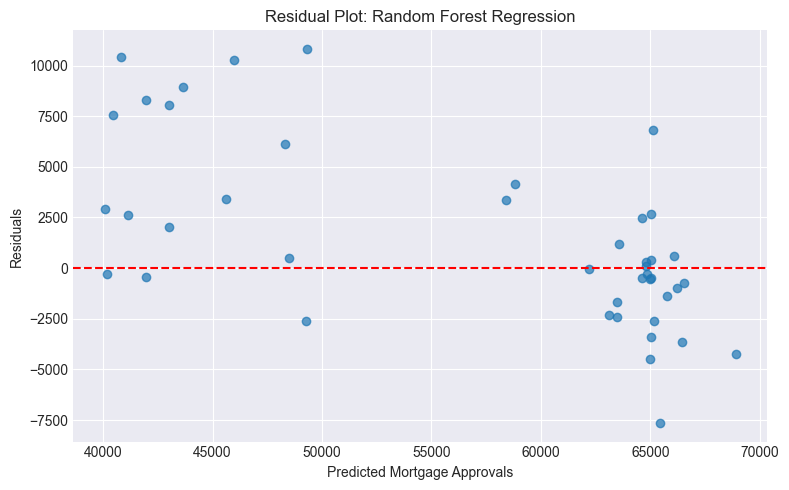

In [34]:
# Calculate residuals
rf_residuals = y_test - y_pred_rf

plt.figure(figsize=(8,5))

plt.scatter(y_pred_rf, rf_residuals, alpha=0.7)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Mortgage Approvals")
plt.ylabel("Residuals")
plt.title("Residual Plot: Random Forest Regression")
plt.tight_layout()
plt.show()

**XGBoost Regression**

In [35]:
from xgboost import XGBRegressor

# Train the XGBoost model
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Generate predictions
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


**XGBoost Feature Importance**

In [36]:
# XGBoost Feature Importance

xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(by="Importance", ascending=False)

xgb_importance

,Feature,Importance
4,Mortgage_Lag1,0.512380
2,GDP_Growth,0.223114
3,Unemployment_Rate,0.131235
0,Bank_Rate,0.093113
1,CPI,0.040157


**XGBoost Evaluation**

In [37]:
xgb_r2 = r2_score(y_test, y_pred_xgb)
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost Results")
print("R² Score :", round(xgb_r2, 4))
print("MAE      :", round(xgb_mae, 2))
print("RMSE     :", round(xgb_rmse, 2))

XGBoost Results
R² Score : 0.7154
MAE      : 3322.13
RMSE     : 4413.14


**Actual vs Predicted Mortgage Approvals**

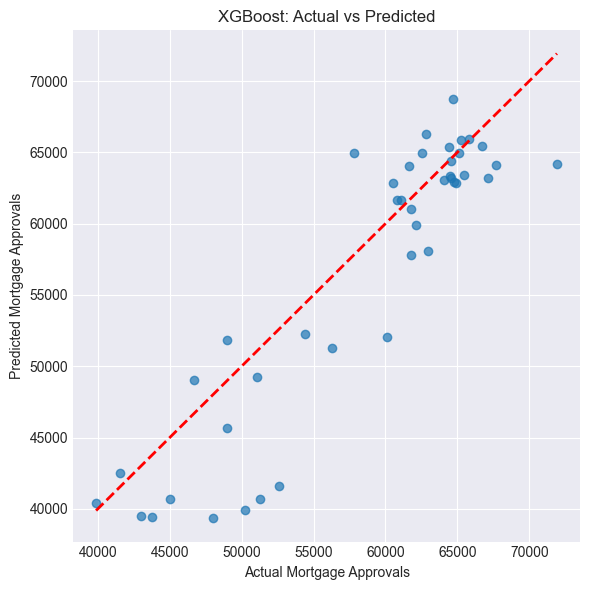

In [38]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_xgb, alpha=0.7)

# 45-degree reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)

plt.xlabel("Actual Mortgage Approvals")
plt.ylabel("Predicted Mortgage Approvals")
plt.title("XGBoost: Actual vs Predicted")
plt.tight_layout()
plt.show()

**Residual Analysis**

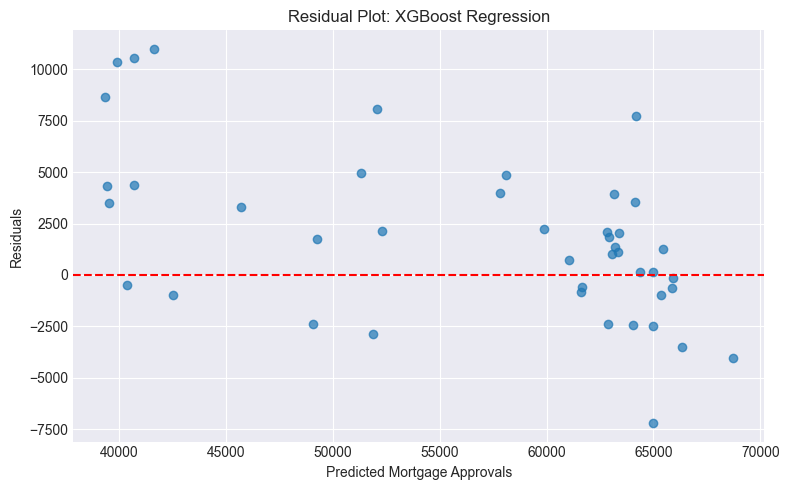

In [39]:
# Calculate residuals
xgb_residuals = y_test - y_pred_xgb

plt.figure(figsize=(8,5))

plt.scatter(y_pred_xgb, xgb_residuals, alpha=0.7)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Mortgage Approvals")
plt.ylabel("Residuals")
plt.title("Residual Plot: XGBoost Regression")
plt.tight_layout()
plt.show()

**Model Comparison**

In [40]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "R²": [lr_r2, rf_r2, xgb_r2],
    "MAE": [lr_mae, rf_mae, xgb_mae],
    "RMSE": [lr_rmse, rf_rmse, xgb_rmse]
})

comparison = comparison.sort_values(by="R²", ascending=False)

comparison

,Model,R²,MAE,RMSE
2,XGBoost,0.715369,3322.134521,4413.144684
1,Random Forest,0.689312,3367.129614,4610.725366
0,Linear Regression,0.425750,5535.457176,6268.415742


**Model Comparison Visualization**

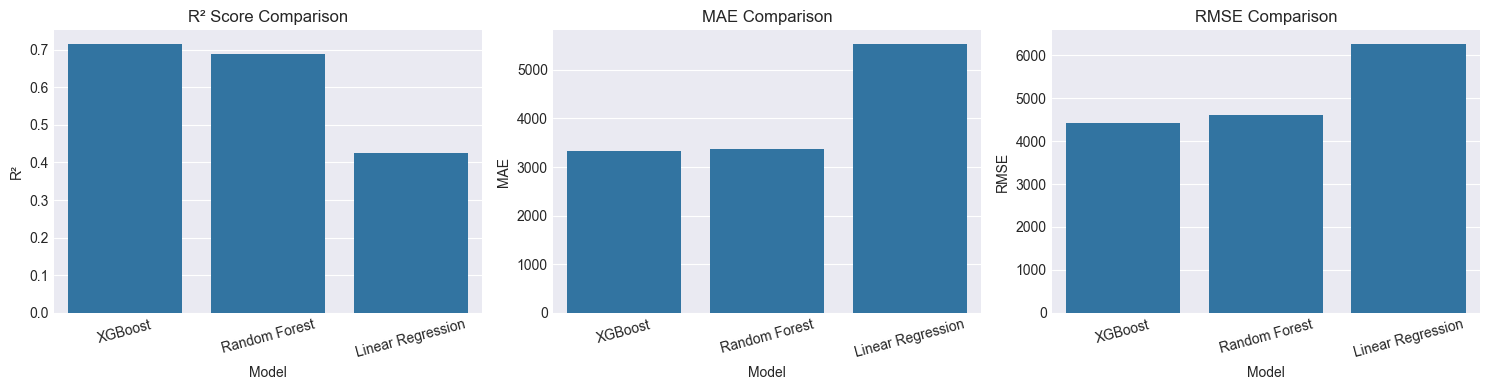

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

# R²
sns.barplot(
    data=comparison,
    x="Model",
    y="R²",
    ax=axes[0]
)
axes[0].set_title("R² Score Comparison")
axes[0].tick_params(axis="x", rotation=15)

# MAE
sns.barplot(
    data=comparison,
    x="Model",
    y="MAE",
    ax=axes[1]
)
axes[1].set_title("MAE Comparison")
axes[1].tick_params(axis="x", rotation=15)

# RMSE
sns.barplot(
    data=comparison,
    x="Model",
    y="RMSE",
    ax=axes[2]
)
axes[2].set_title("RMSE Comparison")
axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

In [42]:
import joblib
import os

os.makedirs("../synthetic_bank/models", exist_ok=True)

In [43]:
joblib.dump(
    xgb_model,
    "../synthetic_bank/models/mortgage_xgb.pkl"
)

print("Mortgage XGBoost model saved successfully.")

Mortgage XGBoost model saved successfully.


In [44]:
mortgage_features = [
    "Bank_Rate",
    "CPI",
    "GDP_Growth",
    "Unemployment_Rate",
    "Mortgage_Lag1"
]

joblib.dump(
    mortgage_features,
    "../synthetic_bank/models/mortgage_features.pkl"
)

print("Mortgage feature list saved successfully.")

Mortgage feature list saved successfully.


In [45]:
latest_mortgage = df["Mortgage_Approvals"].iloc[-1]

joblib.dump(
    latest_mortgage,
    "../synthetic_bank/models/mortgage_latest.pkl"
)

print("Latest Mortgage Approvals:", latest_mortgage)

Latest Mortgage Approvals: 61626
